# Sprint 10

# Nivell 1 

## 1.
Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.
Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.
Mostra les primeres 10 files.
Addicionalment, fes un print on comprovi que el DNI només té valors únic

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, date

data = pd.read_excel('sprint10.xlsx', skiprows=2, header = 1, index_col= 0)
data

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B
996,Joan,García,52145541P,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A
997,Laia,Ferrer Martínez,69760120X,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A
998,Jordi,García,82947791W,Espanya,Barcelona,23,5,1984,H,1.699 €,1.0,NaN,Grup C


In [5]:
data.sort_values(["País d'origen", "Ciutat"], ascending = [True,True], inplace=True)
data.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [6]:
print(data["DNI"].nunique())

1000


## 2.
1. Crea una columna que sigui el nom complet.
2. Crea una columna si la persona és nascuda a Espanya o no.
3. Posa el DNI com a índex del DataFrame (noms de files).
4. Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
5. Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).
6. Mostra tots els canvis que has realitzat en una sola taula.

In [8]:
data["Nom complet"] = data["Nom"] + " " + data["Cognoms"] 

In [9]:
data["Espanyol_a"] = data.apply(lambda row: True if row["País d'origen"] == "Espanya" else False, axis = 1 )

In [10]:
data.set_index("DNI", inplace=True)

In [11]:
data.rename(columns = {"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Any"}, inplace= True)

In [12]:
data.replace(to_replace = {"H": "Home", "D": "Dona", "A": "Altres", "NC": np.nan}, inplace=True)


In [13]:
data

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Espanyol_a
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,False
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,False
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,False


## 3.
Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [15]:
def fill_no_fill(row):
    if row["No Fills"] == 1.0: 
        return "No" 
    else: 
        return "Si"
    
data["Fills"] = data.apply(fill_no_fill, axis = 1)
data.drop(columns = ["No Fills"], inplace= True)

In [16]:
data

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Espanyol_a
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Si,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Si,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Si,Grup D,Jonas Schneider,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,Grup B,Emily Taylor Jones,False
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Si,Grup A,George Brown Jones,False
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,No,Grup A,Olivia Brown Brown,False


## 4.
1. Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
2. Ordena la taula en funció del sou mig.

In [18]:
data["Salari mensual"] = data["Salari mensual"].str.replace("." , "").str.strip('€').astype("int64")

In [19]:
sou_genere = pd.pivot_table(data, index=["Gènere"], values = ["Salari mensual"], aggfunc=["mean", "median", "max", "min"]) 
sou_genere.sort_values([("mean", "Salari mensual")], ascending= False, inplace= True)

In [20]:
sou_genere

,mean,median,max,min
,Salari mensual,Salari mensual,Salari mensual,Salari mensual
Gènere,,,,
Home,1643.249443,1531.0,3356,737
Altres,1626.588235,1545.0,3175,703
Dona,1469.443182,1361.5,3021,665


## 5.
1. Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
2. Afegeix-hi les mitjanes als marges de la taula.
3. (EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

In [22]:
sou_genere_pais = pd.pivot_table(data, index = ["Gènere"], columns = ["País d'origen"], values = ["Salari mensual"], aggfunc= ["mean"], margins= True, margins_name= "Mitjana total", fill_value=0)

In [23]:
sou_genere_pais

mean                                         \
              Salari mensual                                          
País d'origen       Alemanya    Argentina     Colòmbia      Espanya   
Gènere                                                                
Altres            951.000000  1141.000000  1030.000000  1706.176471   
Dona             1804.307692  1291.800000  1497.750000  1460.163987   
Home             2067.428571  1583.294118  1554.666667  1682.105740   
Mitjana total    1851.380952  1463.392857  1495.540541  1581.210059   

                                                                   \
                                                                    
País d'origen       França       Itàlia       Marroc        Mèxic   
Gènere                                                              
Altres            0.000000  1423.000000  1365.000000  1372.000000   
Dona           1566.470588  1247.181818  1405.214286  1517.800000   
Home           1389.250000  1672.875000  1531.000000  1625.000000   
Mitjana total  1462.731707  1425.954545  1447.333333  1558.416667   

                                                       
                                                       
País d'origen     Portugal   Regne Unit Mitjana total  
Gènere                                                 
Altres         1765.000000  1921.000000   1626.588235  
Dona           1488.545455  1489.461538   1469.443182  
Home           1497.000000  1162.555556   1643.249443  
Mitjana total  1523.333333  1423.560000   1560.989362

In [24]:
sou_genere_pais.style.background_gradient(cmap="Purples")

## 6.
1. Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
2. Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [26]:
data["Data neixement"] = pd.to_datetime(dict(day = data.Dia, month =data.Mes, year = data.Any))

In [27]:
def edat(nascut):
    avui = date.today()
    return avui.year - nascut.year - ((avui.month, avui.day) < (nascut.month, nascut.day))

In [28]:
data["Edat"] = data["Data neixement"].apply(edat)

In [29]:
data

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Espanyol_a,Data neixement,Edat
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951,No,Grup A,Mia Schneider Fischer,False,1976-10-22,48
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769,Si,Grup B,Laura Schneider Fischer,False,1958-02-02,67
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013,No,Grup B,Lea Schneider Schneider,False,2005-10-23,19
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557,Si,Grup B,Mia Fischer,False,1950-08-11,74
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754,Si,Grup D,Jonas Schneider,False,1985-11-22,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033,No,Grup B,Emily Taylor Jones,False,1958-03-28,67
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130,Si,Grup A,George Brown Jones,False,1979-12-27,45
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023,No,Grup A,Olivia Brown Brown,False,1952-08-28,72


# Nivell 2

## 1.
Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.

Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

In [32]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":["5%","3,5%","2%","8%"]})
df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


In [33]:
data = data.merge(df_increment, left_on='Grup Professional', right_on='Grup').set_index(data.axes[0])

In [34]:
data["Salari mensual"] = data["Salari mensual"].astype(float) * (1 + (data["Increment"].str.strip("%").str.replace(",",".").astype(float)/100))
data.drop(columns = ["Grup", "Increment"], inplace= True)

In [35]:
data

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Espanyol_a,Data neixement,Edat
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.550,No,Grup A,Mia Schneider Fischer,False,1976-10-22,48
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.915,Si,Grup B,Laura Schneider Fischer,False,1958-02-02,67
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.455,No,Grup B,Lea Schneider Schneider,False,2005-10-23,19
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.495,Si,Grup B,Mia Fischer,False,1950-08-11,74
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.320,Si,Grup D,Jonas Schneider,False,1985-11-22,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.155,No,Grup B,Emily Taylor Jones,False,1958-03-28,67
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.500,Si,Grup A,George Brown Jones,False,1979-12-27,45
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.150,No,Grup A,Olivia Brown Brown,False,1952-08-28,72


## 2.
Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mitjana.

In [37]:
grups = ["A", "B", "C", "D"]

for letra in grups:
    Grup = []
    var = f"dades_Grup{letra}"
    for x in range(len(data)):
        if data.iloc[x]["Grup Professional"] == f"Grup {letra}":
            Grup.append(data.iloc[x])
        
    vars()[var] = pd.DataFrame(Grup, columns = data.columns).to_csv(f"{var}.csv")
    


In [38]:

total_treball = pd.pivot_table(data, index = ["Grup Professional"], 
                                values = ["Salari mensual","Edat"], aggfunc={"Salari mensual": "mean", "Edat":["mean", len]})

total_treball

Edat            Salari mensual
                   len       mean           mean
Grup Professional                               
Grup A             490  48.506122    1213.324286
Grup B             318  47.289308    1724.550849
Grup C             137  50.321168    2289.192701
Grup D              55  44.345455    3100.817455

In [39]:
total_treball.to_csv("data_Grups.csv")

# Nivell 3

## 1.
Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

1. un histograma/boxplot si la variable és numèrica
2. unes barres dels valors més freqüents si és categòrica
3. unes barres dels anys més freqüents si la dada està en format data.
4. La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

- Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

- Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

penguins = sns.load_dataset("penguins")

penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [43]:
def crea_grafic(data):
    
    for column in data.columns:
        print(data[column].dtype)
        if data[column].dtype in (object,str):
            sns.countplot(data = data, x = data[column])
        elif data[column].dtype in (int,float,bool):
            sns.boxplot(data=data, x = data[column])
        elif data[column].dtype in (datetime.date):
            sns.barplot(data = data, x = data[column])
        plt.show()
            
       

object


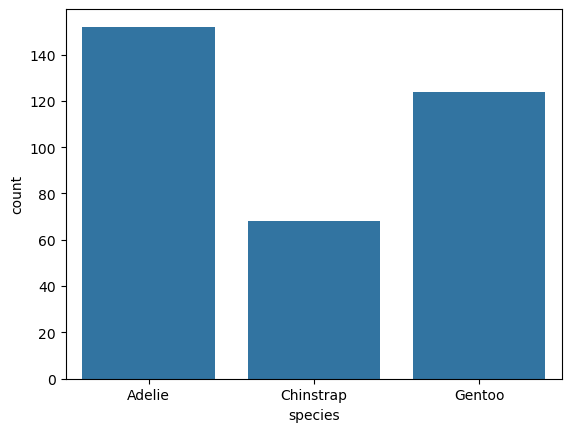

object


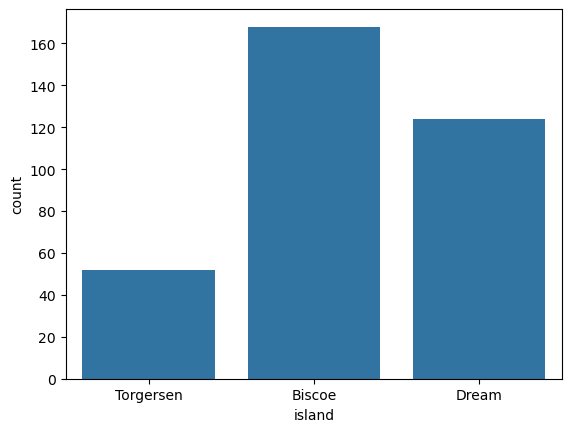

float64


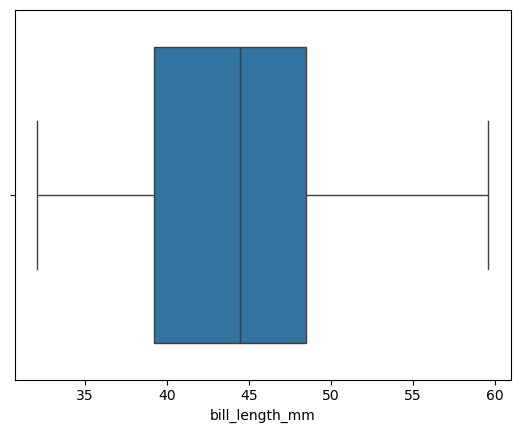

float64


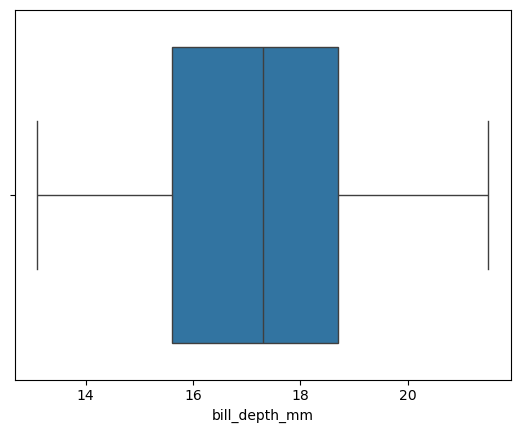

float64


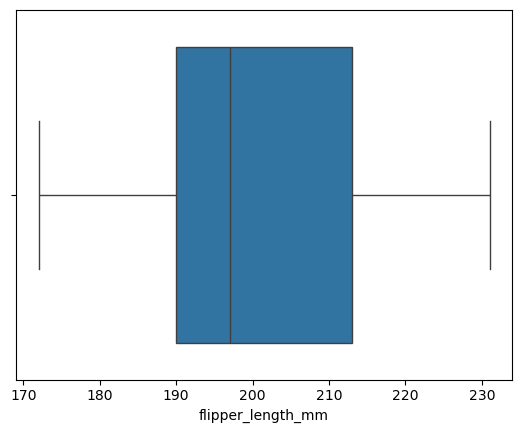

float64


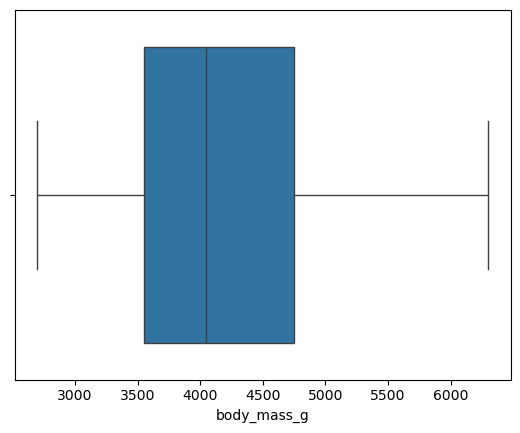

object


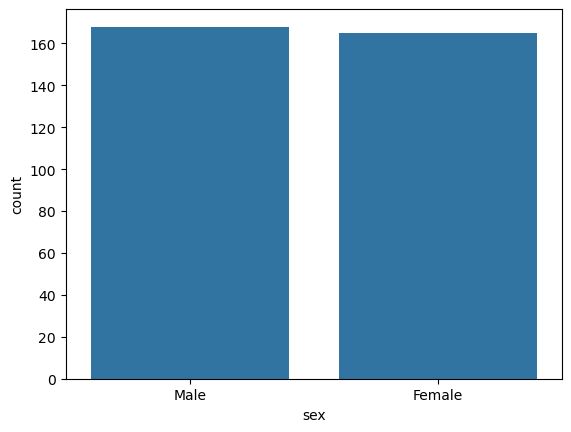

In [44]:
crea_grafic(penguins)

## 2.
1. Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: Mejores Rutas

- Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

- No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

- Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

- Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

- (EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat

- Objectius
    - L’objectiu d’aquest sprint és aplicar de manera pràctica vàries tasques de neteja, resum i analítica de dades utilitzant la llibreria Pandas. Addicionalment també treballaràs en automatizar processos i resoldre problemes complexes.

In [46]:
data = pd.read_excel("matriu_distancies.xlsx", index_col = 0).drop(columns = ["Palma", "Las Palmas de Gran Canaria"],
                                                                   index = ["Palma", "Las Palmas de Gran Canaria"] ).fillna(0)

In [47]:
data

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,0.0,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,0.0,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,0.0,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,0.0,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,0.0,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,0.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,0.0,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,0.0,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,0.0,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,0.0,337.0,224.0,570.0


In [48]:
def calcular_ruta(origen, distancias):
    
    visitadas = [origen]
    no_visitadas = set(distancias.index) - {origen}
    distancia_total = 0
        
    while no_visitadas:
        ultima = ultima = visitadas[-1]
        distancias_validas = distancias.loc[ultima, list(no_visitadas)]
        ciudad_cercana = distancias_validas.idxmin()
        dist = distancias_validas.min() 
        visitadas.append(ciudad_cercana)
        no_visitadas.remove(ciudad_cercana)
        distancia_total += dist
        
    return visitadas, distancia_total


def ruta_optima(distancias, origen):

    if origen not in distancias.index:
        raise ValueError(f"La ciudad de origen '{origen}' no está en la matriz.")
    
    ruta, dist_total = calcular_ruta(origen, distancias)
    mejor_ciudad = origen
    mejor_distancia = dist_total
    for ciudad in distancias.index:
        if ciudad == origen:
            continue
        _, dist = calcular_ruta(ciudad, distancias)
        if dist < mejor_distancia:
            mejor_distancia = dist
            mejor_ciudad = ciudad
    
    return ruta, dist_total, mejor_ciudad

In [49]:
ruta, dist_total, mejor_ciudad = ruta_optima(data, "Barcelona")
print(f"Ruta a seguir: {ruta}")
print(f"Distancia total recorrida: {dist_total}Km") 
print(f"Ciudad con la ruta más corta: {mejor_ciudad}")

Ruta a seguir: ['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Sevilla', 'Córdoba', 'Málaga', 'Murcia', 'Alicante', 'Valencia']
Distancia total recorrida: 2646.0Km
Ciudad con la ruta más corta: Barcelona
